In [15]:
import pandas as pd
import numpy as np
import pyarrow

df = pd.read_parquet('../data/processed/model_df.parquet')


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

def run_aipw(data, covariates, treatment, outcome):
    
    T = data[treatment].astype(int).values
    Y = data[outcome].astype(int).values
    X = data[covariates].copy()

    # Propensity model
    ps_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('logit', LogisticRegression(max_iter=2000))
    ])
    
    ps_model.fit(X, T)
    e_hat = ps_model.predict_proba(X)[:, 1]
    e_hat = np.clip(e_hat, 0.01, 0.99)

    # Outcome models
    model_t = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('logit', LogisticRegression(max_iter=2000))
    ])
    
    model_c = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('logit', LogisticRegression(max_iter=2000))
    ])

    model_t.fit(X[T == 1], Y[T == 1])
    model_c.fit(X[T == 0], Y[T == 0])

    mu1 = model_t.predict_proba(X)[:, 1]
    mu0 = model_c.predict_proba(X)[:, 1]

    aipw_scores = (
        mu1 - mu0
        + T * (Y - mu1) / e_hat
        - (1 - T) * (Y - mu0) / (1 - e_hat)
    )

    return aipw_scores.mean()

In [17]:
covariates = [
    'num_prior_orders',
    'days_since_last_order',
    'customer_tenure_days',
    'prior_total_spend',
    'avg_prior_order_value',
    'payment_value'
]
causal_df = df.copy()

In [18]:
# -----------------------------
# Delay -> Review Score
# Use the existing df you already built
# -----------------------------
import pandas as pd
import numpy as np
import statsmodels.api as sm

review_df = df.copy()

# keep rows where both delay and review exist
review_df = review_df[
    review_df['delivery_delay_days'].notna() &
    review_df['review_score'].notna()
].copy()

# make sure numeric
review_df['delivery_delay_days'] = pd.to_numeric(
    review_df['delivery_delay_days'], errors='coerce'
)
review_df['review_score'] = pd.to_numeric(
    review_df['review_score'], errors='coerce'
)

review_df = review_df.dropna(subset=['delivery_delay_days', 'review_score']).copy()

print("Review analysis sample size:", len(review_df))
print(review_df[['delivery_delay_days', 'review_score']].describe())

Review analysis sample size: 1764
       delivery_delay_days  review_score
count          1764.000000   1764.000000
mean            -13.224490      4.234883
std               8.947921      1.220405
min            -124.000000      1.000000
25%             -17.000000      4.000000
50%             -13.000000      5.000000
75%              -9.000000      5.000000
max              65.000000      5.000000


In [19]:
# -----------------------------
# Simple OLS: review_score ~ delivery_delay_days
# -----------------------------
X = sm.add_constant(review_df['delivery_delay_days'])
y = review_df['review_score']

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     52.57
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           6.19e-13
Time:                        22:45:26   Log-Likelihood:                -2827.9
No. Observations:                1764   AIC:                             5660.
Df Residuals:                    1762   BIC:                             5671.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.9279    

In [20]:
# -----------------------------
# Easy interpretation
# -----------------------------
coef = ols_model.params['delivery_delay_days']
pval = ols_model.pvalues['delivery_delay_days']
r2 = ols_model.rsquared

print(f"Estimated effect of one extra delay day on review score: {coef:.4f}")
print(f"P-value: {pval:.6g}")
print(f"R-squared: {r2:.4f}")

Estimated effect of one extra delay day on review score: -0.0232
P-value: 6.19406e-13
R-squared: 0.0290


In [21]:
# -----------------------------
# Bucket delays to show nonlinear business effect
# -----------------------------
review_df['delay_bucket'] = pd.cut(
    review_df['delivery_delay_days'],
    bins=[-999, -1, 0, 3, 7, 999],
    labels=['early', 'on_time', '1_3_days_late', '4_7_days_late', '7plus_days_late']
)

bucket_summary = (
    review_df.groupby('delay_bucket', observed=False)
    .agg(
        n_orders=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        median_review_score=('review_score', 'median'),
        avg_delay_days=('delivery_delay_days', 'mean')
    )
    .reset_index()
)

print(bucket_summary)

      delay_bucket  n_orders  avg_review_score  median_review_score  \
0            early      1671          4.309595                  5.0   
1          on_time        17          3.911765                  4.0   
2    1_3_days_late        23          2.826087                  3.0   
3    4_7_days_late        29          2.948276                  3.0   
4  7plus_days_late        24          2.166667                  1.0   

   avg_delay_days  
0      -14.324955  
1        0.000000  
2        1.739130  
3        5.620690  
4       16.916667  


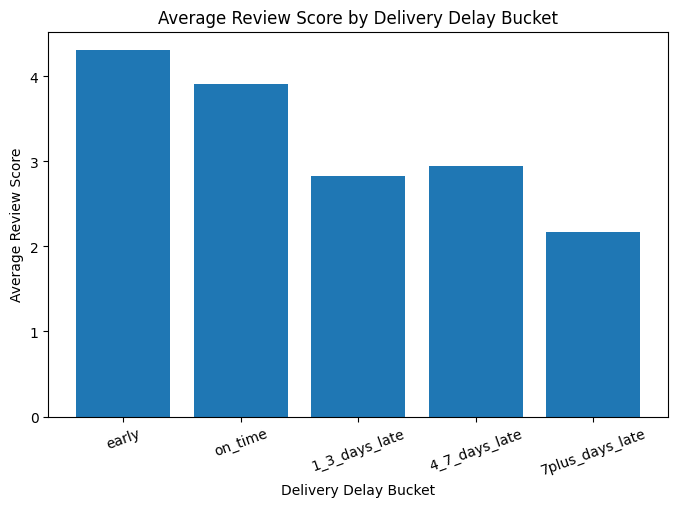

In [22]:
# -----------------------------
# Plot average review score by delay bucket
# -----------------------------
import matplotlib.pyplot as plt

plot_df = bucket_summary.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['delay_bucket'].astype(str), plot_df['avg_review_score'])
plt.xlabel("Delivery Delay Bucket")
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Delivery Delay Bucket")
plt.xticks(rotation=20)
plt.show()

In [23]:

# -----------------------------
# Bad experience metric
# review <= 2 means clearly unhappy customer
# -----------------------------
review_df['low_review'] = (review_df['review_score'] <= 2).astype(int)

low_review_summary = (
    review_df.groupby('delay_bucket', observed=False)
    .agg(
        n_orders=('order_id', 'count'),
        low_review_rate=('low_review', 'mean'),
        avg_review_score=('review_score', 'mean')
    )
    .reset_index()
)

low_review_summary['low_review_rate_pct'] = 100 * low_review_summary['low_review_rate']

print(low_review_summary)

      delay_bucket  n_orders  low_review_rate  avg_review_score  \
0            early      1671         0.089767          4.309595   
1          on_time        17         0.058824          3.911765   
2    1_3_days_late        23         0.478261          2.826087   
3    4_7_days_late        29         0.413793          2.948276   
4  7plus_days_late        24         0.625000          2.166667   

   low_review_rate_pct  
0             8.976661  
1             5.882353  
2            47.826087  
3            41.379310  
4            62.500000  


In [24]:
# -----------------------------
# Logistic model: delay predicts bad review
# -----------------------------
X_bad = sm.add_constant(review_df['delivery_delay_days'])
y_bad = review_df['low_review']

bad_review_model = sm.Logit(y_bad, X_bad).fit()
print(bad_review_model.summary())

Optimization terminated successfully.
         Current function value: 0.329956
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             low_review   No. Observations:                 1764
Model:                          Logit   Df Residuals:                     1762
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                 0.03097
Time:                        22:45:27   Log-Likelihood:                -582.04
converged:                       True   LL-Null:                       -600.64
Covariance Type:            nonrobust   LLR p-value:                 1.067e-09
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.4933      0.123    -12.183      0.000      -1.733      -1.253
de

In [25]:
# -----------------------------
# Stronger treatment versions
# -----------------------------
review_df['delay_gt_3'] = (review_df['delivery_delay_days'] > 3).astype(int)
review_df['delay_gt_7'] = (review_df['delivery_delay_days'] > 7).astype(int)

for treatment_col in ['delay_gt_3', 'delay_gt_7']:
    grouped = review_df.groupby(treatment_col).agg(
        n_orders=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
    grouped['low_review_rate_pct'] = 100 * grouped['low_review_rate']

    print(f"\n=== {treatment_col} ===")
    print(grouped)


=== delay_gt_3 ===
            n_orders  avg_review_score  low_review_rate  low_review_rate_pct
delay_gt_3                                                                  
0               1711           4.28570         0.094681             9.468147
1                 53           2.59434         0.509434            50.943396

=== delay_gt_7 ===
            n_orders  avg_review_score  low_review_rate  low_review_rate_pct
delay_gt_7                                                                  
0               1740          4.263410            0.100                 10.0
1                 24          2.166667            0.625                 62.5


In [26]:
# =============================
# AIPW pivot: severe delay -> bad review
# =============================
causal_df['review_score'] = pd.to_numeric(
    df.loc[causal_df.index, 'review_score'],
    errors='coerce'
)

causal_df['delivery_delay_days'] = pd.to_numeric(
    df.loc[causal_df.index, 'delivery_delay_days'],
    errors='coerce'
)

causal_df['low_review'] = (causal_df['review_score'] <= 2).astype(float)
causal_df['delay_gt_3'] = (causal_df['delivery_delay_days'] > 3).astype(int)
causal_df['delay_gt_7'] = (causal_df['delivery_delay_days'] > 7).astype(int)

review_causal_df = causal_df.dropna(
    subset=['review_score', 'delivery_delay_days']
).copy()

print("Review-causal sample shape:", review_causal_df.shape)
print("Low review rate:", review_causal_df['low_review'].mean())
print("delay_gt_3 treatment rate:", review_causal_df['delay_gt_3'].mean())
print("delay_gt_7 treatment rate:", review_causal_df['delay_gt_7'].mean())

Review-causal sample shape: (1764, 14)
Low review rate: 0.10714285714285714
delay_gt_3 treatment rate: 0.030045351473922902
delay_gt_7 treatment rate: 0.013605442176870748


In [27]:
# =============================
# AIPW estimates
# =============================
ate_delay3_lowreview = run_aipw(
    review_causal_df,
    covariates,
    'delay_gt_3',
    'low_review'
)

ate_delay7_lowreview = run_aipw(
    review_causal_df,
    covariates,
    'delay_gt_7',
    'low_review'
)

print("AIPW ATE: delay > 3 days on low_review =", round(ate_delay3_lowreview, 4))
print("Interpretation: a delay > 3 days changes bad-review probability by",
      f"{ate_delay3_lowreview * 100:.2f} percentage points on average.")

print("\nAIPW ATE: delay > 7 days on low_review =", round(ate_delay7_lowreview, 4))
print("Interpretation: a delay > 7 days changes bad-review probability by",
      f"{ate_delay7_lowreview * 100:.2f} percentage points on average.")

AIPW ATE: delay > 3 days on low_review = 0.398
Interpretation: a delay > 3 days changes bad-review probability by 39.80 percentage points on average.

AIPW ATE: delay > 7 days on low_review = 0.5236
Interpretation: a delay > 7 days changes bad-review probability by 52.36 percentage points on average.


In [28]:
# =============================
# Bootstrap confidence intervals for the AIPW estimates
# =============================
import numpy as np

def bootstrap_aipw(data, covariates, treatment, outcome, B=300, seed=42):
    rng = np.random.default_rng(seed)
    ates = []

    data = data.reset_index(drop=True).copy()

    for b in range(B):
        idx = rng.choice(len(data), size=len(data), replace=True)
        sample = data.iloc[idx].copy()

      
        if sample[treatment].nunique() < 2:
            continue
        if sample[outcome].nunique() < 2:
            continue

        try:
            ate_b = run_aipw(sample, covariates, treatment, outcome)
            ates.append(ate_b)
        except Exception:
            continue

    ci_low, ci_high = np.percentile(ates, [2.5, 97.5])
    return np.mean(ates), ci_low, ci_high, len(ates)

mean3, ci3_low, ci3_high, b3 = bootstrap_aipw(
    review_causal_df, covariates, 'delay_gt_3', 'low_review', B=300, seed=42
)

mean7, ci7_low, ci7_high, b7 = bootstrap_aipw(
    review_causal_df, covariates, 'delay_gt_7', 'low_review', B=300, seed=42
)

print("=== delay_gt_3 -> low_review ===")
print("Bootstrap runs used:", b3)
print(f"AIPW ATE: {mean3:.4f}")
print(f"95% CI: ({ci3_low:.4f}, {ci3_high:.4f})")

print("\n=== delay_gt_7 -> low_review ===")
print("Bootstrap runs used:", b7)
print(f"AIPW ATE: {mean7:.4f}")
print(f"95% CI: ({ci7_low:.4f}, {ci7_high:.4f})")

=== delay_gt_3 -> low_review ===
Bootstrap runs used: 300
AIPW ATE: 0.4069
95% CI: (0.2458, 0.5537)

=== delay_gt_7 -> low_review ===
Bootstrap runs used: 300
AIPW ATE: 0.5511
95% CI: (0.3200, 0.7798)


In [29]:

for treatment_col in ['delay_gt_3', 'delay_gt_7']:
    tmp = review_causal_df.groupby(treatment_col).agg(
        n=('low_review', 'size'),
        low_review_rate=('low_review', 'mean')
    )
    tmp['low_review_rate_pct'] = 100 * tmp['low_review_rate']

    print(f"\n=== {treatment_col} raw rates ===")
    print(tmp)


=== delay_gt_3 raw rates ===
               n  low_review_rate  low_review_rate_pct
delay_gt_3                                            
0           1711         0.094681             9.468147
1             53         0.509434            50.943396

=== delay_gt_7 raw rates ===
               n  low_review_rate  low_review_rate_pct
delay_gt_7                                            
0           1740            0.100                 10.0
1             24            0.625                 62.5


In [30]:

review_causal_df['loyalty_bucket'] = pd.qcut(
    review_causal_df['num_prior_orders'],
    q=4,
    duplicates='drop'
)

print("=== Heterogeneous effects by loyalty quartile ===")
for bucket in sorted(review_causal_df['loyalty_bucket'].dropna().unique()):
    sub = review_causal_df[review_causal_df['loyalty_bucket'] == bucket].copy()

    if len(sub) < 100:
        continue
    if sub['delay_gt_3'].nunique() < 2:
        continue
    if sub['low_review'].nunique() < 2:
        continue

    ate_sub = run_aipw(sub, covariates, 'delay_gt_3', 'low_review')
    print(f"{bucket} | n={len(sub)} | ATE={ate_sub:.4f}")

=== Heterogeneous effects by loyalty quartile ===
(0.999, 8.0] | n=1764 | ATE=0.3980


In [31]:
# define repeat customer
review_df['is_repeat'] = (review_df['num_prior_orders'] > 1).astype(int)

repeat_summary = review_df.groupby('low_review').agg(
    n=('order_id', 'count'),
    repeat_rate=('is_repeat', 'mean'),
    avg_order_value=('payment_value', 'mean')
).reset_index()

print(repeat_summary)

   low_review     n  repeat_rate  avg_order_value
0           0  1575     0.100952        138.06094
1           1   189     0.058201        164.05127


In [39]:
delta_repeat = repeat_summary.loc[0, 'repeat_rate'] - repeat_summary.loc[1, 'repeat_rate']
avg_order_value = review_df['payment_value'].mean()

value_per_saved_customer = delta_repeat * avg_order_value

print("Value of preventing one bad experience:", value_per_saved_customer)

Value of preventing one bad experience: 6.0213364695437255


In [33]:
num_delayed_orders = review_df['delay_gt_7'].sum()

reduction_rate = 0.10  #reduce delays by 10%

orders_fixed = num_delayed_orders * reduction_rate

bad_reviews_prevented = orders_fixed * 0.5422

revenue_saved = bad_reviews_prevented * value_per_saved_customer

print("Estimated revenue saved:", revenue_saved)

Estimated revenue saved: 7.83544472108786


In [34]:
cost_per_bad_review = avg_order_value * 0.2  # assume 20% future value loss
revenue_loss = bad_reviews_prevented * cost_per_bad_review
print(f"{revenue_loss} is the amount of revenue lost")

36.655917135782325 is the amount of revenue lost


In [35]:
total_orders = len(review_df)
avg_loss_per_order = revenue_loss  

total_loss = total_orders * avg_loss_per_order

print("Total potential loss:", total_loss)

Total potential loss: 64661.03782752002


In [36]:

def compute_risk_metrics(df, treatment_col, outcome_col):
    summary = df.groupby(treatment_col).agg(
        n=(outcome_col, 'size'),
        risk=(outcome_col, 'mean')
    ).reset_index()

    control_risk = summary.loc[summary[treatment_col] == 0, 'risk'].values[0]
    treated_risk = summary.loc[summary[treatment_col] == 1, 'risk'].values[0]

    risk_diff = treated_risk - control_risk
    risk_ratio = treated_risk / control_risk if control_risk > 0 else np.nan

    return summary, control_risk, treated_risk, risk_diff, risk_ratio


# -----------------------------
# Delay > 3 days
# -----------------------------
summary_3, p0_3, p1_3, rd_3, rr_3 = compute_risk_metrics(
    review_df, 'delay_gt_3', 'low_review'
)

print("=== Risk Exposure: Delay > 3 Days ===")
print(summary_3)
print(f"Baseline risk (no severe delay): {p0_3:.4f}")
print(f"Treated risk (delay > 3): {p1_3:.4f}")
print(f"Absolute increase (risk difference): {rd_3:.4f}")
print(f"Relative increase (risk ratio): {rr_3:.2f}x")


# -----------------------------
# Delay > 7 days
# -----------------------------
summary_7, p0_7, p1_7, rd_7, rr_7 = compute_risk_metrics(
    review_df, 'delay_gt_7', 'low_review'
)

print("\n=== Risk Exposure: Delay > 7 Days ===")
print(summary_7)
print(f"Baseline risk (no severe delay): {p0_7:.4f}")
print(f"Treated risk (delay > 7): {p1_7:.4f}")
print(f"Absolute increase (risk difference): {rd_7:.4f}")
print(f"Relative increase (risk ratio): {rr_7:.2f}x")

=== Risk Exposure: Delay > 3 Days ===
   delay_gt_3     n      risk
0           0  1711  0.094681
1           1    53  0.509434
Baseline risk (no severe delay): 0.0947
Treated risk (delay > 3): 0.5094
Absolute increase (risk difference): 0.4148
Relative increase (risk ratio): 5.38x

=== Risk Exposure: Delay > 7 Days ===
   delay_gt_7     n   risk
0           0  1740  0.100
1           1    24  0.625
Baseline risk (no severe delay): 0.1000
Treated risk (delay > 7): 0.6250
Absolute increase (risk difference): 0.5250
Relative increase (risk ratio): 6.25x


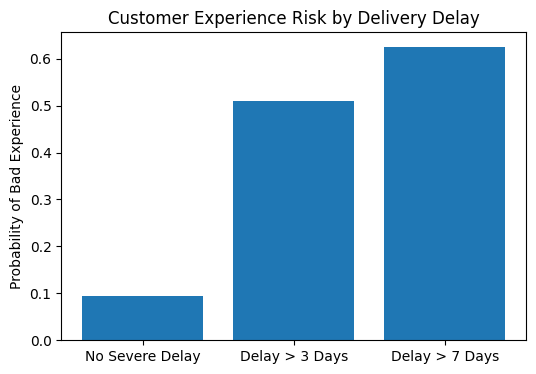

In [37]:
import matplotlib.pyplot as plt

labels = ['No Severe Delay', 'Delay > 3 Days', 'Delay > 7 Days']
risks = [p0_3, p1_3, p1_7]

plt.figure(figsize=(6,4))
plt.bar(labels, risks)
plt.ylabel("Probability of Bad Experience")
plt.title("Customer Experience Risk by Delivery Delay")
plt.show()

In [38]:
review_df.columns

Index(['order_id', 'customer_unique_id', 'delivery_delay_days', 'review_score',
       'payment_value', 'num_prior_orders', 'days_since_last_order',
       'customer_tenure_days', 'prior_total_spend', 'avg_prior_order_value',
       'churn_90d', 'delay_bucket', 'low_review', 'delay_gt_3', 'delay_gt_7',
       'is_repeat'],
      dtype='str')

In [ ]:
dashboard_df = review_df.copy()

dashboard_df = dashboard_df[[
    'order_id',
    'delivery_delay_days',
    'delay_bucket',
    'low_review',
    'review_score',
    'payment_value',
    'delay_gt_3',
    'delay_gt_7'
]]

dashboard_df.to_csv("tableau_orders.csv", index=False)

In [ ]:
bucket_summary = review_df.groupby('delay_bucket').agg(
    n_orders=('order_id', 'count'),
    low_review_rate=('low_review', 'mean'),
    avg_order_value=('payment_value', 'mean')
).reset_index()

bucket_summary['low_review_rate_pct'] = 100 * bucket_summary['low_review_rate']

bucket_summary.to_csv("tableau_delay_bucket_summary.csv", index=False)

In [ ]:
bucket_summary = (
    review_df.groupby('delay_bucket')
    .agg(
        n_orders=('order_id', 'count'),
        low_review_rate=('low_review', 'mean'),
        avg_order_value=('payment_value', 'mean')
    )
    .reset_index()
)

bucket_summary['low_review_rate_pct'] = 100 * bucket_summary['low_review_rate']

bucket_summary.to_csv("tableau_delay_bucket_summary.csv", index=False)

In [ ]:
risk_metrics_df = pd.DataFrame({
    'metric': [
        'baseline_risk',
        'risk_delay_gt_3',
        'risk_delay_gt_7',
        'risk_diff_3',
        'risk_diff_7',
        'risk_ratio_3',
        'risk_ratio_7'
    ],
    'value': [
        p0_3,
        p1_3,
        p1_7,
        p1_3 - p0_3,
        p1_7 - p0_7,
        p1_3 / p0_3,
        p1_7 / p0_7
    ]
})

risk_metrics_df.to_csv("tableau_risk_metrics.csv", index=False)

In [ ]:
causal_results_df = pd.DataFrame({
    'treatment': ['delay_gt_3', 'delay_gt_7'],
    'ate': [mean3, mean7],
    'ci_lower': [ci3_low, ci7_low],
    'ci_upper': [ci3_high, ci7_high]
})

causal_results_df['ate_pct'] = 100 * causal_results_df['ate']
causal_results_df['ci_lower_pct'] = 100 * causal_results_df['ci_lower']
causal_results_df['ci_upper_pct'] = 100 * causal_results_df['ci_upper']

causal_results_df.to_csv("tableau_causal_results.csv", index=False)

In [ ]:
monetization_df = pd.DataFrame({
    'metric': [
        'value_per_bad_experience',
        'example_revenue_saved'
    ],
    'value': [
        value_per_saved_customer,
        revenue_saved
    ]
})

monetization_df.to_csv("tableau_monetization.csv", index=False)